# Overlap of the contact groups (all runs pooled)

Four 3-set Venn diagrams: **PDB** (Inter PDB, Intra PDB, No contact PDB) and **AlphaFold** (Inter PDB, Intra AF,
No contact AF), each with the inter- and intra-chain groups defined by **distance** (`dist4.5`: NZ within 4.5 A of a
non-adjacent polymer atom) or by **salt bridge**. No contact is always the distance definition (no contact within
4.5 A in any chain copy of that source). Inter-chain always comes from the PDB structures.

A peptide is in a group if one of its lysines is (no contact: all its lysines). Counted: unique peptides
(Uniprot, peptide_seq) with a shared-charge MS_DSA in at least one run (the flags do not depend on the run).

In [1]:
import matplotlib.pyplot as plt
from dsa.ms_dsa.evaluation1.ms_dsa_annotator import MSDSAAnnotator
from dsa.ms_dsa.evaluation1.plots import contact_venn

plt.rcParams.update({"font.size": 8, "figure.dpi": 100})
ms_dsa_by_run = {run_index: MSDSAAnnotator.load_run(run_index) for run_index in range(5)}

In [2]:
# settings
dsa_column = "MS_DSA_shared_charges"
exclude = ["channel_absent", "no_shared_charges"]    # version A; add "zero_area_shared" for version B
unit = "peptide"                                     # or "peptide-run" to count (peptide, run) pairs

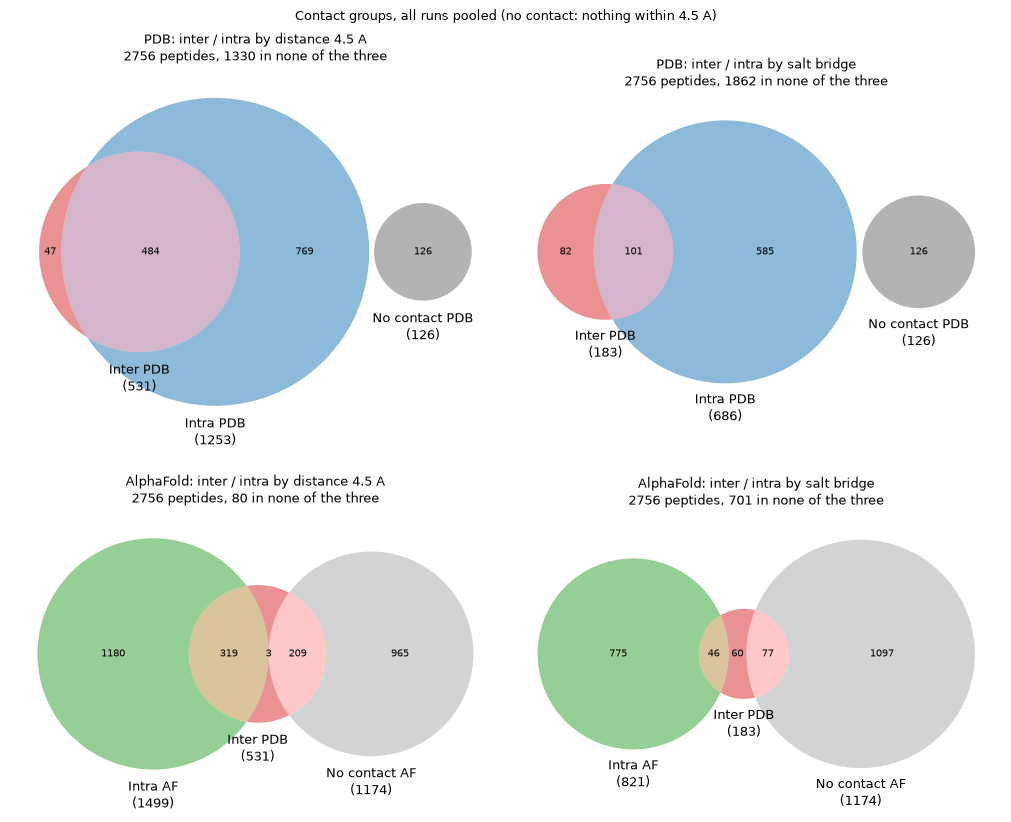

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8.5), constrained_layout=True)
for row, (sasa_source, label) in enumerate([("multimer", "PDB"), ("monomer", "AlphaFold")]):
    for col, (contact_class, class_label) in enumerate([("dist4.5", "distance 4.5 A"), ("salt_bridge", "salt bridge")]):
        contact_venn(ms_dsa_by_run, contact_class, sasa_source, dsa_column, exclude, unit,
                     title=f"{label}: inter / intra by {class_label}", ax=axes[row][col])
fig.suptitle("Contact groups, all runs pooled (no contact: nothing within 4.5 A)")
plt.show()